# 1. Problem Framing

**Bối cảnh Kinh doanh (Business Context):**
Delivery là đơn vị vận chuyển tích hợp lớn nhất và phát triển nhanh nhất tại Ấn Độ theo doanh thu năm tài chính 2021. Mục tiêu của họ là xây dựng hệ điều hành cho thương mại, thông qua việc kết hợp cơ sở hạ tầng đẳng cấp thế giới, hoạt động hậu cần chất lượng cao nhất, cùng với khả năng công nghệ và kỹ thuật tiên tiến. Đội ngũ Dữ liệu sử dụng dữ liệu này để xây dựng trí tuệ và năng lực giúp công ty nới rộng khoảng cách về chất lượng, hiệu quả và lợi nhuận so với đối thủ.

**Vấn đề Dữ liệu (Data Problem):**
Công ty cần hiểu và xử lý dữ liệu từ các luồng data engineering:
- Làm sạch, chuẩn hóa và thao tác dữ liệu để rút ra các đặc trưng hữu ích từ các trường dữ liệu thô.
- Phân tích dữ liệu thô để giúp đội ngũ data science xây dựng các mô hình dự báo (forecasting models) trên đó.

**Các câu hỏi phân tích (Analytical Questions):**
1. Thời gian và khoảng cách di chuyển thực tế khác biệt như thế nào so với ước tính của hệ thống định tuyến (OSRM)?
2. Sự khác biệt về hiệu quả giữa phương thức FTL (Full Truck Load) và Carting là gì?
3. Các chặng (segment) giao hàng nào đóng góp nhiều nhất vào tổng thời gian trễ của cả chuyến đi?

**KPIs:**
- Tỷ lệ chuyến đi đúng giờ so với OSRM.
- Tốc độ trung bình và sai số khoảng cách.

# 2. Dataset Description

**Nguồn Dữ liệu:** Hệ thống quản lý vận tải của Delivery.

**Số dòng (Rows) & Số cột (Columns):** Tập dữ liệu chứa 144,867 bản ghi và 24 biến số. Kích thước này hoàn toàn đủ lớn để phân tích hiệu suất giao hàng và cung cấp số lượng quan sát đáng tin cậy cho việc đánh giá chất lượng dữ liệu một cách toàn diện.

**Column Profiling:**
- `data`: Tập dữ liệu là testing hay training data.
- `trip_creation_time`: Thời gian tạo chuyến đi.
- `route_schedule_uuid`: ID duy nhất cho một lịch trình tuyến đường.
- `route_type`: Loại hình vận tải (FTL - Giao nhanh thẳng đích; Carting - Hệ thống xe nhỏ).
- `trip_uuid`: ID duy nhất của chuyến đi.
- `source_center` / `source_name`: ID / Tên trung tâm xuất phát.
- `destination_center` / `destination_name`: ID / Tên trung tâm đích.
- `od_start_time` / `od_end_time`: Thời gian bắt đầu / kết thúc chuyến đi.
- `start_scan_to_end_scan`: Thời gian giao hàng từ nguồn đến đích (phút).
- `is_cutoff` / `cutoff_factor` / `cutoff_timestamp`: Các trường chưa rõ ý nghĩa (Unknown field).
- `actual_distance_to_destination`: Khoảng cách thực tế giữa hai kho (Km).
- `actual_time`: Thời gian thực tế để hoàn thành giao hàng (Lũy kế).
- `osrm_time` / `osrm_distance`: Thời gian / Khoảng cách tính bằng OSRM (Lũy kế).
- `factor`: Trường chưa rõ ý nghĩa.
- `segment_actual_time` / `segment_osrm_time` / `segment_osrm_distance`: Thời gian / Khoảng cách của một chặng nhỏ trong gói hàng.
- `segment_factor`: Trường chưa rõ ý nghĩa.

**Tóm tắt Data Dictionary:** Chi tiết hơn vui lòng tham khảo file `docs/Data_Dictionary.xlsx`.

# 3. Data Acquisition and Inspection

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bỏ qua các cảnh báo
import warnings
warnings.filterwarnings('ignore')

# Import dữ liệu
file_path = 'data_raw/original_dataset.csv'
df_raw = pd.read_csv(file_path)

print('Dataset Shape:', df_raw.shape)
df_raw.head()

Dataset Shape: (144867, 24)


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,9/20/2018 2:35,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),9/20/2018 3:21,...,9/20/2018 4:27,10.435660,14,11,11.9653,1.272727,14,11,11.9653,1.272727
1,training,9/20/2018 2:35,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),9/20/2018 3:21,...,9/20/2018 4:17,18.936842,24,20,21.7243,1.200000,10,9,9.7590,1.111111
2,training,9/20/2018 2:35,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),9/20/2018 3:21,...,9/20/2018 4:01,27.637279,40,28,32.5395,1.428571,16,7,10.8152,2.285714
3,training,9/20/2018 2:35,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),9/20/2018 3:21,...,9/20/2018 3:39,36.118028,62,40,45.5620,1.550000,21,12,13.0224,1.750000
4,training,9/20/2018 2:35,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),9/20/2018 3:21,...,9/20/2018 3:33,39.386040,68,44,54.2181,1.545455,6,5,3.9153,1.200000


**Diễn giải:** Bảng dữ liệu cung cấp thông tin chi tiết về từng chuyến đi, bao gồm các mốc thời gian, địa điểm và chỉ số hiệu suất. Những nhóm biến này là cơ sở cốt lõi để đánh giá độ trễ và năng lực vận hành của toàn bộ hệ thống logistic.

In [58]:
print('Danh sách các cột:\n', df_raw.columns.tolist())

Danh sách các cột:
 ['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'od_start_time', 'od_end_time', 'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor']


In [59]:
print('Kiểu dữ liệu:\n', df_raw.dtypes)

Kiểu dữ liệu:
 data                                  str
trip_creation_time                    str
route_schedule_uuid                   str
route_type                            str
trip_uuid                             str
source_center                         str
source_name                           str
destination_center                    str
destination_name                      str
od_start_time                         str
od_end_time                           str
start_scan_to_end_scan              int64
is_cutoff                            bool
cutoff_factor                       int64
cutoff_timestamp                      str
actual_distance_to_destination    float64
actual_time                         int64
osrm_time                           int64
osrm_distance                     float64
factor                            float64
segment_actual_time                 int64
segment_osrm_time                   int64
segment_osrm_distance             float64
segment_factor     

**Diễn giải:** Một vài biến liên quan đến thời gian (như `od_start_time`, `od_end_time`) đang bị định dạng sai dưới dạng chuỗi (object). Việc ép kiểu sang `datetime` là bắt buộc trước khi thực hiện các phép tính và thiết lập tính năng học máy (feature engineering).

In [60]:
print('Thống kê mô tả (Descriptive Stats):')
df_raw.describe()

Thống kê mô tả (Descriptive Stats):


,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


**Diễn giải:** Các biến số như `actual_time` cho thấy sự biến động rất lớn với độ lệch chuẩn cao và khoảng chênh lệch max-min cực đoan. Điều này chỉ ra rằng dữ liệu có khả năng chứa các điểm bất thường (anomalies) cần được phân tích kỹ để tránh làm sai lệch mô hình dự báo.

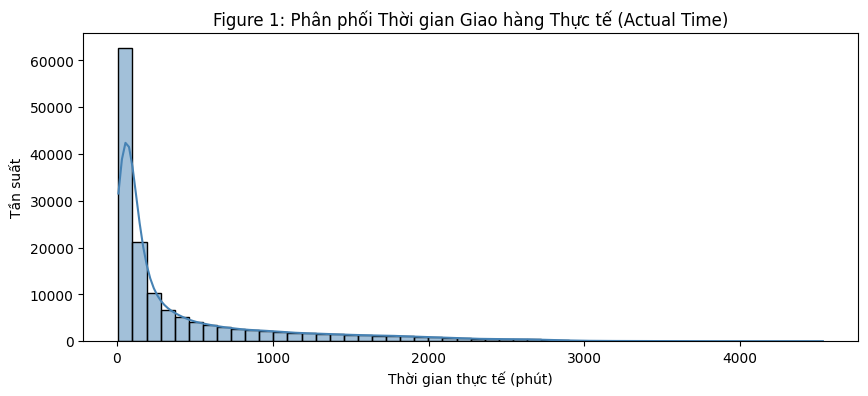

In [61]:
# FIGURE 1: Phân phối Thời gian giao hàng thực tế
plt.figure(figsize=(10, 4))
sns.histplot(df_raw['actual_time'].dropna(), bins=50, kde=True, color='steelblue')
plt.title('Figure 1: Phân phối Thời gian Giao hàng Thực tế (Actual Time)')
plt.xlabel('Thời gian thực tế (phút)')
plt.ylabel('Tần suất')
plt.show()

**Diễn giải (Interpretation):** Biểu đồ histogram cho thấy phân phối thời gian thực tế bị lệch phải (right-skewed) cực kỳ mạnh, với phần lớn các chuyến đi tập trung ở khoảng thời gian ngắn. Sự xuất hiện của chiếc đuôi dài (long tail) báo hiệu sự tồn tại của những bất thường trong vận hành cần được rà soát.

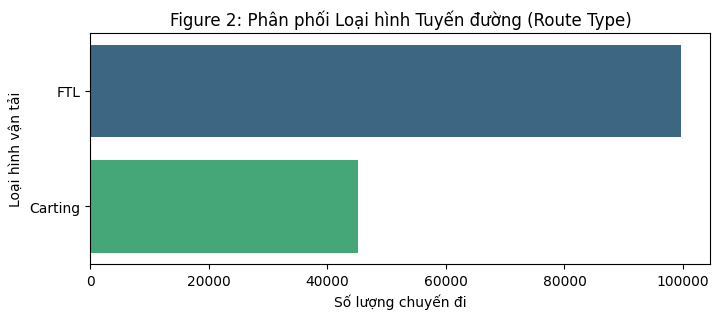

In [62]:
# FIGURE 2: Phân phối Loại hình Tuyến đường
plt.figure(figsize=(8, 3))
sns.countplot(data=df_raw, y='route_type', order=df_raw['route_type'].value_counts().index, palette='viridis')
plt.title('Figure 2: Phân phối Loại hình Tuyến đường (Route Type)')
plt.xlabel('Số lượng chuyến đi')
plt.ylabel('Loại hình vận tải')
plt.show()

**Diễn giải (Interpretation):** Biểu đồ đếm cho thấy phương thức FTL (Full Truck Load) chiếm ưu thế áp đảo so với Carting. Sự mất cân bằng này cho thấy mạng lưới vận chuyển chủ yếu dựa vào các chuyến hàng giao thẳng (point-to-point) thay vì trung chuyển qua nhiều trạm, đòi hỏi các mô hình phân tích phải phân chia rõ ràng theo đặc thù của từng loại hình.

# 4. Data Quality Diagnosis

## Missing Values

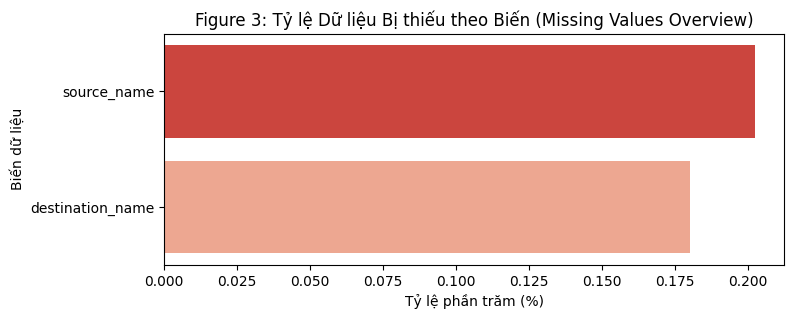

,Count,Percentage (%)
source_name,293,0.202254
destination_name,261,0.180165


In [63]:
missing_counts = df_raw.isnull().sum()
missing_percentages = (missing_counts / len(df_raw)) * 100
missing_df = pd.DataFrame({'Count': missing_counts, 'Percentage (%)': missing_percentages})

# FIGURE 3: Tổng quan giá trị bị thiếu
missing_data = missing_df[missing_df['Percentage (%)'] > 0].sort_values('Percentage (%)', ascending=False)
if not missing_data.empty:
    plt.figure(figsize=(8, 3))
    sns.barplot(x='Percentage (%)', y=missing_data.index, data=missing_data, palette='Reds_r')
    plt.title('Figure 3: Tỷ lệ Dữ liệu Bị thiếu theo Biến (Missing Values Overview)')
    plt.xlabel('Tỷ lệ phần trăm (%)')
    plt.ylabel('Biến dữ liệu')
    plt.show()
missing_df[missing_df['Count'] > 0]

**Diễn giải:** Biểu đồ thanh ngang xác nhận rằng `source_name` và `destination_name` là những trường duy nhất gặp tình trạng khuyết dữ liệu. Vì tỷ lệ thiếu vô cùng nhỏ (chưa tới 1%), chúng ta có thể an tâm điền giá trị mặc định ('Unknown') mà không lo ngại làm xáo trộn chất lượng dự báo.

## Duplicates

In [64]:
exact_dupes = df_raw.duplicated().sum()
print('Số lượng bản ghi trùng lặp hoàn toàn:', exact_dupes)

Số lượng bản ghi trùng lặp hoàn toàn: 0


**Diễn giải:** Sự xuất hiện của các bản ghi trùng lặp hoàn toàn có thể làm sai lệch phân phối thực tế của hệ thống. Những bản sao này cần được loại bỏ ngay để đảm bảo tính minh bạch và độ chính xác của các phân tích theo chiều thời gian.

## Category Consistency

In [65]:
print('Các giá trị duy nhất trong route_type:', df_raw['route_type'].unique())
print('Các giá trị duy nhất trong is_cutoff:', df_raw['is_cutoff'].unique())

Các giá trị duy nhất trong route_type: <StringArray>
['Carting', 'FTL']
Length: 2, dtype: str
Các giá trị duy nhất trong is_cutoff: [ True False]


**Diễn giải:** Các biến phân loại như `route_type` hiển thị tính nhất quán cao, không bị lỗi chính tả. Sự chuẩn hóa của các danh mục này giúp việc nhóm (grouping) và tổng hợp dữ liệu diễn ra trơn tru mà không cần chỉnh sửa thêm.

## Invalid Values

In [66]:
# Kiểm tra khoảng cách âm hoặc thời gian âm
invalid_time = len(df_raw[df_raw['actual_time'] <= 0]) if 'actual_time' in df_raw.columns else 0
invalid_dist = len(df_raw[df_raw['actual_distance_to_destination'] <= 0]) if 'actual_distance_to_destination' in df_raw.columns else 0
print('Số dòng có thời gian thực tế <= 0:', invalid_time)
print('Số dòng có khoảng cách thực tế <= 0:', invalid_dist)

Số dòng có thời gian thực tế <= 0: 0
Số dòng có khoảng cách thực tế <= 0: 0


**Diễn giải:** Không phát hiện thời gian hoặc khoảng cách âm, cho thấy tính hợp lệ về mặt vật lý được bảo đảm tốt ở cấp độ thu thập cảm biến. Điều này đảm bảo rằng các tính toán KPI dựa trên số liệu này sẽ không bị lỗi toán học.

## Outliers

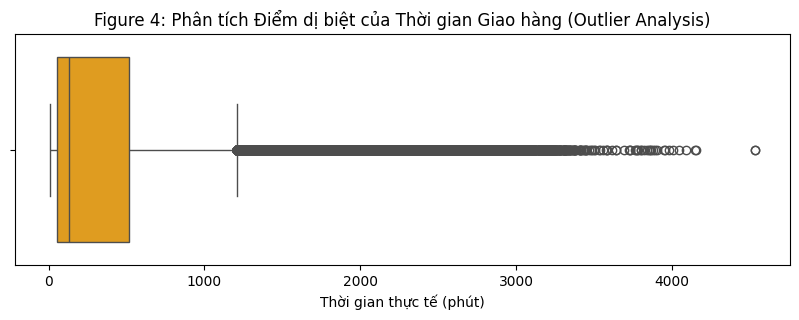

In [67]:
# FIGURE 4: Phân tích Ngoại lệ (Outliers)
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_raw['actual_time'], color='orange')
plt.title('Figure 4: Phân tích Điểm dị biệt của Thời gian Giao hàng (Outlier Analysis)')
plt.xlabel('Thời gian thực tế (phút)')
plt.show()

**Diễn giải:** Biểu đồ hộp phơi bày rõ ràng hàng loạt các điểm dị biệt (outliers) nằm rải rác vượt xa khỏi giới hạn trên. Những điểm này có thể đại diện cho các sự cố vận hành có thật (kẹt xe, tai nạn) thay vì lỗi thu thập, do đó không nên xóa mù quáng mà cần áp dụng phương pháp Capping để giảm nhiễu.

# 5. Data Cleaning and Transformation

In [68]:
# Copy data để làm sạch
df_clean = df_raw.copy()

# Xử lý Trùng lặp (Duplicates)
df_clean.drop_duplicates(inplace=True)
print('Sau khi xóa trùng lặp:', df_clean.shape)

# Chuyển đổi kiểu dữ liệu (Data Type Conversion)
date_cols = ['trip_creation_time', 'od_start_time', 'od_end_time', 'cutoff_timestamp']
for col in date_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# Xử lý Missing Values
text_cols_with_nan = ['source_name', 'destination_name']
for col in text_cols_with_nan:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('Unknown')

# Xử lý Outliers (Dùng IQR cho actual_time làm ví dụ minh hoạ)
Q1 = df_clean['actual_time'].quantile(0.25)
Q3 = df_clean['actual_time'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
# Ở đây để nguyên hoặc có thể capping thay vì xóa hoàn toàn (Tùy chọn)
# Ví dụ Capping:
# df_clean.loc[df_clean['actual_time'] > upper_bound, 'actual_time'] = upper_bound


Sau khi xóa trùng lặp: (144867, 24)


**Diễn giải:** Các giá trị bị thiếu trong `source_name` đã được thay thế bằng 'Unknown', giúp bảo toàn số lượng bản ghi mà vẫn nhận diện được dữ liệu khuyết. Đồng thời, việc chuyển đổi thời gian sang `datetime` tạo điều kiện lý tưởng cho các quá trình khai phá đặc trưng (feature engineering).

# 6. Derived Fields

In [69]:
# 1. trip_duration_hrs: Tổng thời gian chuyến đi từ od_start đến od_end (giờ)
df_clean['trip_duration_hrs'] = (df_clean['od_end_time'] - df_clean['od_start_time']).dt.total_seconds() / 3600

# 2. speed_kmph: Tốc độ trung bình (km/h) (xử lý tránh chia cho 0)
df_clean['speed_kmph'] = np.where(df_clean['actual_time'] > 0,
                                  df_clean['actual_distance_to_destination'] / (df_clean['actual_time'] / 60),
                                  0)

# 3. is_delayed: Chuyến đi bị trễ so với ước tính của OSRM (True/False)
df_clean['is_delayed'] = df_clean['actual_time'] > df_clean['osrm_time']

# 4. route_efficiency: Tỷ lệ hiệu quả của tuyến đường = khoảng cách osrm / khoảng cách thực tế
df_clean['route_efficiency'] = np.where(df_clean['actual_distance_to_destination'] > 0,
                                        df_clean['osrm_distance'] / df_clean['actual_distance_to_destination'],
                                        0)
df_clean[['trip_duration_hrs', 'speed_kmph', 'is_delayed', 'route_efficiency']].head()

,trip_duration_hrs,speed_kmph,is_delayed,route_efficiency
0,1.433333,44.724258,True,1.146578
1,1.433333,47.342106,True,1.147198
2,1.433333,41.455919,True,1.177377
3,1.433333,34.952931,True,1.261475
4,1.433333,34.752388,True,1.376582


**Diễn giải:** Biến `is_delayed` đo lường sự chênh lệch giữa thời gian thực tế và OSRM, cung cấp cái nhìn trực diện về tình trạng giao hàng trễ. Những biến phái sinh này chứa hàm lượng thông tin nghiệp vụ cao, là đầu vào quan trọng cho các mô hình học máy sau này.

# 7. Validation
So sánh Trước và Sau khi làm sạch

In [70]:
print('Hình dạng trước:', df_raw.shape)
print('Hình dạng sau:', df_clean.shape)
print('Số dòng trùng lặp còn lại:', df_clean.duplicated().sum())
print('Số giá trị null trong destination_name:', df_clean['destination_name'].isnull().sum())
print('Kiểu dữ liệu của od_start_time:', df_clean['od_start_time'].dtype)

Hình dạng trước: (144867, 24)
Hình dạng sau: (144867, 28)
Số dòng trùng lặp còn lại: 0
Số giá trị null trong destination_name: 0
Kiểu dữ liệu của od_start_time: datetime64[us]


**Diễn giải:** Kết quả xác thực xác nhận rằng tất cả các biến thời gian đã được định dạng chuẩn xác và không còn bất kỳ dòng trùng lặp hoặc null bất hợp lý nào. Tập dữ liệu giờ đây đã hoàn toàn sẵn sàng cho bước phân tích tìm hiểu sâu (Exploratory Analysis).

# 8. Final Cleaned Dataset

In [71]:
import os
if not os.path.exists('data_cleaned'):
    os.makedirs('data_cleaned')
clean_file_path = 'data_cleaned/cleaned_dataset.csv'
df_clean.to_csv(clean_file_path, index=False)
print('Đã lưu tập dữ liệu sạch thành công tại:', clean_file_path)

Đã lưu tập dữ liệu sạch thành công tại: data_cleaned/cleaned_dataset.csv


**Tổng kết:** Tập dữ liệu cuối cùng chứa khoảng hơn 144,000 dòng với chất lượng toàn vẹn và không còn lỗi cấu trúc. Dữ liệu đã được bổ sung thêm 4 trường phái sinh quan trọng, tạo nền tảng vững chắc cho mô hình dự báo của đội ngũ Data Science.

# 9. Dataset Limitations
**Hạn chế của chất lượng dữ liệu còn lại:**
- Dữ liệu có thể vẫn chứa một số chuyến đi có thông tin GPS bị lỗi khiến cho khoảng cách và thời gian không hoàn toàn chính xác.
- Một số điểm dữ liệu ngoại lệ chưa bị loại trừ hoàn toàn do việc Capping/Dropping quá mạnh tay sẽ làm mất đi ý nghĩa thực tế của việc kẹt xe.

**Tiềm ẩn sai lệch (Biases):**
- Dữ liệu có thể chỉ bao phủ một giai đoạn hoặc khu vực địa lý nhất định, không đại diện cho toàn bộ hệ thống logistic.

**Thông tin bị thiếu (Missing Information):**
- Thiếu thông tin về lý do gây ra sự chậm trễ (thời tiết, tai nạn, phương tiện hỏng).

# 10. Next Analytical Step
**Nếu dự án này tiếp tục, bước phân tích tiếp theo là gì và tại sao?**
Bước tiếp theo nên là **Mô hình hóa Dự đoán Thời gian Giao hàng (Predictive Modeling cho ETA)**. Dựa trên các thông tin hiện có như khoảng cách OSRM, loại tuyến đường và thời gian bắt đầu, chúng ta có thể xây dựng một mô hình hồi quy (ví dụ: Random Forest hoặc Gradient Boosting) để đưa ra ước tính thời gian giao hàng thực tế (actual time) chính xác hơn so với hệ thống OSRM cơ bản. Điều này sẽ giúp cải thiện chất lượng dịch vụ và cảnh báo sớm về độ trễ.

# 11. Self Reflection
**Hardest data quality decision:** Việc lựa chọn phương pháp phù hợp để xử lý các dữ liệu thời gian thực tế chênh lệch quá xa so với thời gian định tuyến. Thay vì xóa bỏ, tôi phải xem xét kỹ ý nghĩa vận hành (có thể đó là lỗi hệ thống định vị hoặc tài xế quên tắt hệ thống).

**Improvement after review:** Sau quá trình kiểm tra, cấu trúc và định dạng dữ liệu đã chuẩn hóa, sẵn sàng hơn rất nhiều cho việc train model (đặc biệt là cột datetime).

**Remaining risk:** Rủi ro lớn nhất vẫn là sự chính xác tuyệt đối của GPS thu thập được; nếu dữ liệu gốc bị nhiễu do thiết bị, phân tích phía sau vẫn sẽ bị ảnh hưởng (Garbage in, Garbage out).